<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1050617/541765151.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X_plot, y_plot, label='Predictive $\mu$', linestyle='--', alpha=0.6, color='k')


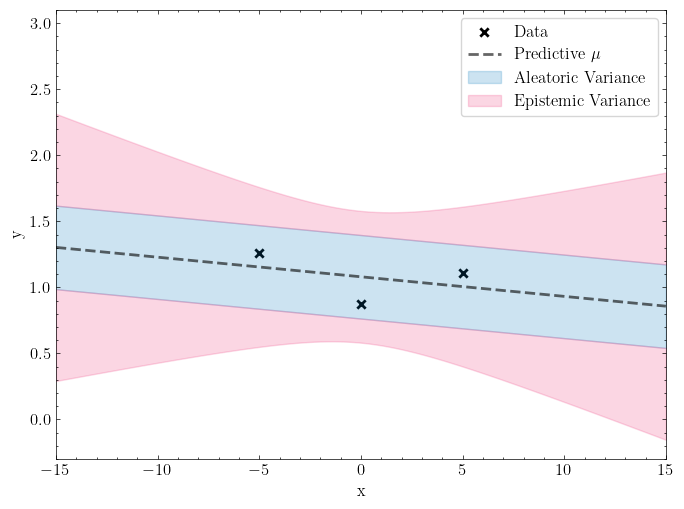

In [42]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('fullstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Generate synthetic data
np.random.seed(0)

# Hyperparameters
sigma2 = 0.1 # Variance of the noise
tau2 = 30  # Prior variance
slope = 0.01
offset = 0.75
n = 3

X = np.linspace(-5, 5, n)

y = slope * X + offset + np.random.normal(0, np.sqrt(sigma2), n)

# Add a column of ones for the intercept term
X = np.vstack((np.ones(n), X)).T

# Posterior calculations
Sigma_prior = tau2 * np.eye(2)
Sigma_post = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma2) * X.T @ X)
mu_post = Sigma_post @ ((1 / sigma2) * X.T @ y)

# Predictive posterior distribution
def predictive_distribution(x_new, mu_post, Sigma_post, sigma2):
    x_new = np.array([1, x_new])
    mean = x_new @ mu_post
    epistemic_variance = x_new @ Sigma_post @ x_new.T 
    aleatoric_variance = sigma2
    return mean, np.sqrt(epistemic_variance), np.sqrt(aleatoric_variance) 

# Plotting
X_plot = np.linspace(-15, 15, 100)
y_plot = [predictive_distribution(x, mu_post, Sigma_post, sigma2)[0] for x in X_plot]
y_std_epistemic = [predictive_distribution(x, mu_post, Sigma_post, sigma2)[1] for x in X_plot]
y_std_aleatoric = [predictive_distribution(x, mu_post, Sigma_post, sigma2)[2] for x in X_plot]

plt.figure()
plt.scatter(X[:, 1], y, marker='x', label='Data', color='k')
plt.plot(X_plot, y_plot, label='Predictive $\mu$', linestyle='--', alpha=0.6, color='k')
plt.fill_between(X_plot, np.array(y_plot) - np.array(y_std_aleatoric), np.array(y_plot) + np.array(y_std_aleatoric), color=colors[1], alpha=0.2, label='Aleatoric Variance')
plt.fill_between(X_plot, np.array(y_plot) - np.array(y_std_aleatoric) - np.array(y_std_epistemic), np.array(y_plot) - np.array(y_std_aleatoric), color=colors[3], alpha=0.2, label='Epistemic Variance')
plt.fill_between(X_plot, np.array(y_plot) + np.array(y_std_aleatoric), np.array(y_plot) + np.array(y_std_aleatoric) + np.array(y_std_epistemic), color=colors[3], alpha=0.2)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([-15, 15])
plt.ylim([-0.3, 3.1])
plt.legend()
plt.tight_layout()
plt.savefig("outputs/bayesian_linear_regression_homoscedatic.pdf", format='pdf', bbox_inches='tight')


<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1050617/10594802.py:114: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X_plot_features, y_plot_mean, label='Predictive $\mu$', linestyle='--', alpha=0.6, color='k', zorder=2)


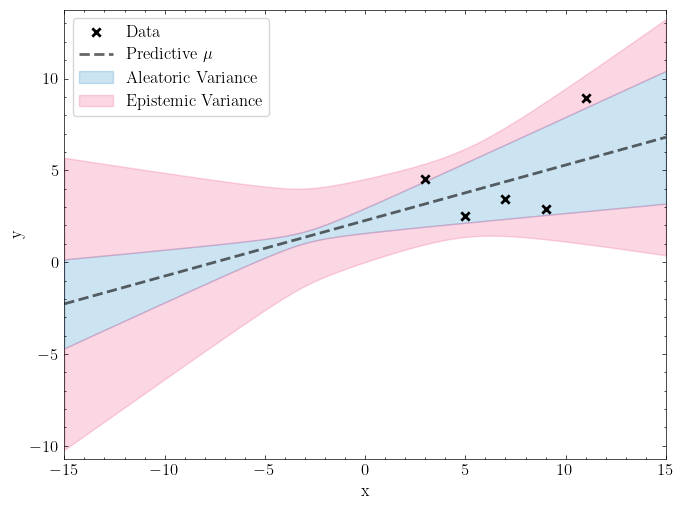

Posterior Mean (theta): [2.26533194 0.30240846]
True parameters: offset=1.0, slope=0.5


In [43]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('fullstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Generate synthetic data
np.random.seed(1)

# --- Hyperparameters & Data Generation Setup ---
# True parameters for data generation
true_slope = 0.5
true_offset = 1.0

num_samples = 5  # Number of data points

# Feature values for training data
X_features = np.linspace(3, 11, num_samples)
#X_features = np.concat([np.linspace(-5, 5, num_samples), np.random.rand(num_samples)*2 - 5], axis=0)
#num_samples = np.size(X_features)

# Heteroscedastic noise variances for each TRAINING observation
# Variance increases quadratically with X_features
# This defines how sigma_i^2 (for training data) depends on x_i
def noise_variance_model(x_values):
    return 0.1 + 0.04 * (x_values+3)**2

sigma2_observations = noise_variance_model(X_features)

# Generate observations y_i = slope * x_i + offset + epsilon_i
# where epsilon_i ~ N(0, sigma2_observations_i)
noise_obs = np.random.normal(0, np.sqrt(sigma2_observations), num_samples)
y_observations = true_slope * X_features + true_offset + noise_obs

# Design matrix: Add a column of ones for the intercept term
# X_design has shape (num_samples, num_model_params)
X_design = np.vstack((np.ones(num_samples), X_features)).T
num_model_params = X_design.shape[1] # Should be 2 (intercept, slope)

# Prior variance for theta
tau2 = 10.0  # Prior variance (scalar, assuming isotropic prior)

# --- Posterior Calculations (Heteroscedastic) ---
# Prior covariance matrix for theta (num_model_params x num_model_params)
Sigma_prior_inv = (1 / tau2) * np.eye(num_model_params)

# Inverse of the observation noise covariance matrix S for TRAINING data
# S is diagonal with sigma2_observations_i on the diagonal.
# S_inv is diagonal with 1/sigma2_observations_i on the diagonal.
S_inv_diag = 1.0 / sigma2_observations

# Efficient calculation of X^T S^-1 X and X^T S^-1 y
XT_S_inv_X = (X_design.T * S_inv_diag) @ X_design
XT_S_inv_y = (X_design.T * S_inv_diag) @ y_observations

# Posterior covariance matrix for theta
Sigma_post = np.linalg.inv(Sigma_prior_inv + XT_S_inv_X)

# Posterior mean for theta
mu_post = Sigma_post @ XT_S_inv_y

# --- Predictive Posterior Distribution Function ---
def predictive_distribution(x_new_feature, mu_post_params, Sigma_post_params, sigma2_noise_new):
    """
    Calculates the predictive mean, epistemic standard deviation, and aleatoric standard deviation
    for a new data point x_new_feature.

    Args:
        x_new_feature (float): The feature value of the new data point.
        mu_post_params (np.array): Posterior mean of theta.
        Sigma_post_params (np.array): Posterior covariance of theta.
        sigma2_noise_new (float): KNOWN noise variance for this new data point.
    
    Returns:
        tuple: (mean, epistemic_std, aleatoric_std)
    """
    x_new_design = np.array([1, x_new_feature])
    mean_pred = x_new_design @ mu_post_params
    epistemic_variance = x_new_design @ Sigma_post_params @ x_new_design.T
    aleatoric_variance = sigma2_noise_new
    
    return mean_pred, np.sqrt(epistemic_variance), np.sqrt(aleatoric_variance)

# --- Plotting ---
# Define the range for plotting predictions
X_plot_features = np.linspace(-15, 15, 200)

y_plot_mean = []
y_plot_epistemic_std = []
y_plot_aleatoric_std = []

for x_val in X_plot_features:
    # *** CRITICAL CHANGE FOR VARYING ALEATORIC BAND ***
    # Assume the noise variance for NEW predictions (sigma_star^2)
    # follows the same model as the training data noise.
    sigma2_noise_new_for_this_x = noise_variance_model(x_val)

    mean, epistemic_std, aleatoric_std = predictive_distribution(
        x_val, mu_post, Sigma_post, sigma2_noise_new_for_this_x # Use varying sigma2 for aleatoric
    )
    y_plot_mean.append(mean)
    y_plot_epistemic_std.append(epistemic_std)
    y_plot_aleatoric_std.append(aleatoric_std) # This will now vary with x_val

y_plot_mean = np.array(y_plot_mean)
y_plot_epistemic_std = np.array(y_plot_epistemic_std)
y_plot_aleatoric_std = np.array(y_plot_aleatoric_std) # Now an array of varying values

plt.figure()

# Plot data points
plt.scatter(X_features, y_observations, marker='x', label='Data', color='k', zorder=3)

# Plot predictive mean
plt.plot(X_plot_features, y_plot_mean, label='Predictive $\mu$', linestyle='--', alpha=0.6, color='k', zorder=2)

# Plot aleatoric uncertainty band (around the mean)
# This band width now varies based on sigma_star^2(x_*)
plt.fill_between(X_plot_features,
                 y_plot_mean - y_plot_aleatoric_std,
                 y_plot_mean + y_plot_aleatoric_std,
                 color=colors[1], alpha=0.2, label='Aleatoric Variance')

# Plot epistemic uncertainty band (added to the aleatoric band)
plt.fill_between(X_plot_features,
                 y_plot_mean - y_plot_aleatoric_std - y_plot_epistemic_std,
                 y_plot_mean - y_plot_aleatoric_std,
                 color=colors[3], alpha=0.2, label='Epistemic Variance')
plt.fill_between(X_plot_features,
                 y_plot_mean + y_plot_aleatoric_std,
                 y_plot_mean + y_plot_aleatoric_std + y_plot_epistemic_std,
                 color=colors[3], alpha=0.2)


plt.xlabel('x')
plt.ylabel('y')
#plt.title('Bayesian Linear Regression with Heteroscedastic Noise\n(Varying Aleatoric Uncertainty for Predictions)')
plt.legend(loc='upper left')
#plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim([-15, 15])

# Adjust y-limits based on data and predictions
min_y_plot = (y_plot_mean - y_plot_aleatoric_std - y_plot_epistemic_std).min()
max_y_plot = (y_plot_mean + y_plot_aleatoric_std + y_plot_epistemic_std).max()
min_data = y_observations.min()
max_data = y_observations.max()
plt.ylim([min(min_y_plot, min_data) - 0.5, max(max_y_plot, max_data) + 0.5])

plt.tight_layout()
plt.savefig("outputs/bayesian_linear_regression_heteroscedatic.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("Posterior Mean (theta):", mu_post)
print(f"True parameters: offset={true_offset}, slope={true_slope}")
# print("Posterior Covariance (theta):\n", Sigma_post) # Can be verbose

<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21826/547813098.py:110: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(X_plot, mean_pred, linestyle='--', color='k', alpha=0.7, label='Predictive $\mu$', zorder=3)


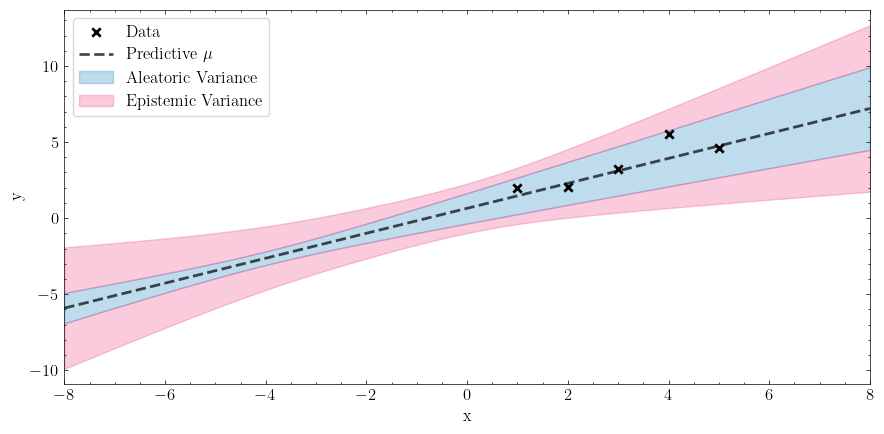

Posterior mean m_post = [0.6426 0.8202]
True parameters: offset = 1.0 , slope = 0.4
PDF saved to: /mnt/data/bayesian_linear_regression_heteroscedastic.pdf


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0.  Matplotlib style — use user's file if available
# ------------------------------------------------------------
try:
    plt.style.use('fullstyle.mplstyle')
except OSError:
    pass

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ------------------------------------------------------------
# 1.  DATA GENERATION  (general Gaussian noise, correlated)
# ------------------------------------------------------------
np.random.seed(42)

true_offset = 1.0
true_slope  = 0.4

num_samples = 5
X_features  = np.linspace(1.0, 5.0, num_samples)

# Heteroscedastic marginal variances for each observation
def noise_variance_model(x):
    """σ²(x) = 0.2 + 0.05 x²   (strictly positive)."""
    return 0.2 + 0.05 * (x+4)**2

sigma2_i = noise_variance_model(X_features)
sigma_i  = np.sqrt(sigma2_i)

# Correlation structure between observation errors ----------------
# Simple AR(1) correlation by index distance:
rho = 0.6
indices = np.arange(num_samples)
corr_matrix = rho ** np.abs(indices[:, None] - indices[None, :])

# Assemble full covariance Σ_noise = D C D  (D = diag(σ_i))
Sigma_noise = (sigma_i[:, None] * sigma_i[None, :]) * corr_matrix

# Draw correlated noise ε ~ N(0, Σ_noise)
L = np.linalg.cholesky(Sigma_noise)
eps = L @ np.random.randn(num_samples)

# Generate responses
y_observations = true_offset + true_slope * X_features + eps

# ------------------------------------------------------------
# 2.  PRIOR  (general Gaussian with non-diagonal covariance)
# ------------------------------------------------------------
m0 = np.array([0.0, 0.0])                       # prior mean (2,)
Sigma0 = np.array([[1.0, 0.8],                  # general positive-definite Σ₀
                   [0.8, 1.5]])
Sigma0_inv = np.linalg.inv(Sigma0)

# ------------------------------------------------------------
# 3.  POSTERIOR (closed form with general noise)
# ------------------------------------------------------------
# Design matrix for affine line: [1, x]
X_design = np.vstack((np.ones(num_samples), X_features)).T   # (N,2)

Lambda_noise = np.linalg.inv(Sigma_noise)                    # precision Σ_noise⁻¹

# Compute Xᵀ Λ X  and  Xᵀ Λ y
XT_Lambda = X_design.T @ Lambda_noise
XT_Lambda_X = XT_Lambda @ X_design
XT_Lambda_y = XT_Lambda @ y_observations

Sigma_post = np.linalg.inv( Sigma0_inv + XT_Lambda_X )
m_post     = Sigma_post @ ( XT_Lambda_y + Sigma0_inv @ m0 )

# ------------------------------------------------------------
# 4.  PREDICTIVE  (mean, epistemic var, aleatoric var)
# ------------------------------------------------------------
def predictive_stats(x_new):
    """Return mean, sqrt(epistemic var), sqrt(aleatoric var) at x_new."""
    phi = np.array([1.0, x_new])           # design vector
    mean = phi @ m_post
    var_epistemic = phi @ Sigma_post @ phi.T
    var_aleatoric = noise_variance_model(x_new)   # assumed known functional form
    return mean, np.sqrt(var_epistemic), np.sqrt(var_aleatoric)

X_plot = np.linspace(-8.0, 8.0, 400)

mean_pred      = []
std_epistemic  = []
std_aleatoric  = []

for x_val in X_plot:
    mu, se, sa = predictive_stats(x_val)
    mean_pred.append(mu)
    std_epistemic.append(se)
    std_aleatoric.append(sa)

mean_pred     = np.asarray(mean_pred)
std_epistemic = np.asarray(std_epistemic)
std_aleatoric = np.asarray(std_aleatoric)

# ------------------------------------------------------------
# 5.  VISUALISATION
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

# Raw data
ax.scatter(X_features, y_observations, marker='x', color='k', label='Data', zorder=4)

# Predictive mean
ax.plot(X_plot, mean_pred, linestyle='--', color='k', alpha=0.7, label='Predictive $\mu$', zorder=3)

# Aleatoric band
ax.fill_between(
    X_plot,
    mean_pred - std_aleatoric,
    mean_pred + std_aleatoric,
    color=colors[1] if len(colors) > 1 else 'tab:orange',
    alpha=0.25,
    label='Aleatoric Variance'
)

# Epistemic band (outside aleatoric)
ax.fill_between(
    X_plot,
    mean_pred - std_aleatoric - std_epistemic,
    mean_pred - std_aleatoric,
    color=colors[3] if len(colors) > 3 else 'tab:pink',
    alpha=0.25,
    label='Epistemic Variance'
)
ax.fill_between(
    X_plot,
    mean_pred + std_aleatoric,
    mean_pred + std_aleatoric + std_epistemic,
    color=colors[3] if len(colors) > 3 else 'tab:pink',
    alpha=0.25
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([X_plot.min(), X_plot.max()])

# y-limits to include all uncertainty
y_min = np.min(mean_pred - std_aleatoric - std_epistemic)
y_max = np.max(mean_pred + std_aleatoric + std_epistemic)
ax.set_ylim([y_min - 1.0, y_max + 1.0])

ax.legend(loc='upper left')
fig.tight_layout()

# ------------------------------------------------------------
# 6.  SAVE  (optional download link)
# ------------------------------------------------------------
#os.makedirs('/mnt/data', exist_ok=True)
#pdf_path = '/mnt/data/blr_general_noise_prior.pdf'
#fig.savefig(pdf_path, format='pdf', bbox_inches='tight')

plt.show()

print("Posterior mean m_post =", m_post.round(4))
print("True parameters: offset =", true_offset, ", slope =", true_slope)
print("PDF saved to:", pdf_path)


<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_503215/2807959195.py:38: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(label='$p(\\theta \mid \mathcal{D})$')


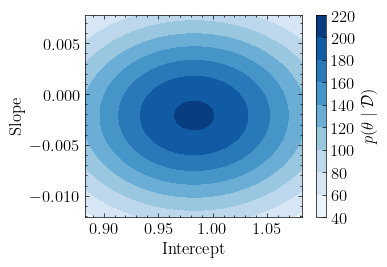

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
plt.style.use('halfstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Generate synthetic data
np.random.seed(0)

# Hyperparameters
sigma2 = 0.1 # Variance of the noise
tau2 = 30  # Prior variance
slope = 0.01
offset = 0.75
n = 10

X = np.linspace(-20, 20, n)

y = slope * X + offset + np.random.normal(0, np.sqrt(sigma2), n)

# Add a column of ones for the intercept term
X = np.vstack((np.ones(n), X)).T

# Posterior calculations
Sigma_prior = tau2 * np.eye(2)
Sigma_post = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma2) * X.T @ X)
mu_post = Sigma_post @ ((1 / sigma2) * X.T @ y)

# Plotting the posterior distribution of parameters
theta_0, theta_1 = np.mgrid[mu_post[0] - 0.1:mu_post[0] + 0.1:0.001,
                            mu_post[1] - 0.01:mu_post[1] + 0.01:0.0001]

pos = np.dstack((theta_0, theta_1))
rv = multivariate_normal(mu_post, Sigma_post)

plt.figure()
plt.contourf(theta_0, theta_1, rv.pdf(pos), cmap='Blues')
plt.colorbar(label='$p(\\theta \mid \mathcal{D})$')
plt.xlabel('Intercept')
plt.ylabel('Slope')
#plt.title('Posterior Distribution over Parameters')
#plt.tight_layout()
plt.savefig("outputs/linear_regression_distribution_parameters.pdf", format='pdf', bbox_inches='tight')


<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_115580/815535181.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot([0,0], [0,0], color=colors[1], alpha=0.65, label="Models Sampled from $p(\\theta\mid\mathcal{D})$")


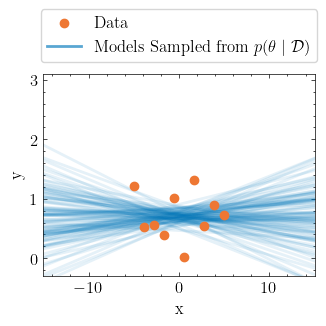

In [11]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('halfstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# Generate synthetic data
np.random.seed(1)

# Hyperparameters
sigma2 = 0.1  # Variance of the noise
tau2 = 30  # Prior variance
slope = 0.01
offset = 0.75
n = 10

X = np.linspace(-5, 5, n)

y = slope * X + offset + np.random.normal(0, np.sqrt(sigma2), n)

# Add a column of ones for the intercept term
X = np.vstack((np.ones(n), X)).T

# Posterior calculations
Sigma_prior = tau2 * np.eye(2)
Sigma_post = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma2) * X.T @ X)
mu_post = Sigma_post @ ((1 / sigma2) * X.T @ y)

# Sampling from the posterior distribution of parameters
n_samples = 100
samples = np.random.multivariate_normal(mu_post, Sigma_post, n_samples)

# Plotting
plt.figure()
plt.scatter(X[:, 1], y, label='Data', color=colors[0], alpha=1, zorder=3)

# Plot sampled linear models
X_plot = np.linspace(-15, 15, 100)
for theta in samples[:-1]:
    y_sampled = theta[0] + theta[1] * X_plot
    plt.plot(X_plot, y_sampled, color=colors[1], alpha=0.1)

y_sampled = theta[0] + theta[1] * X_plot
plt.plot([0,0], [0,0], color=colors[1], alpha=0.65, label="Models Sampled from $p(\\theta\mid\mathcal{D})$")

# Plot the mean line from the posterior
y_mean = mu_post[0] + mu_post[1] * X_plot
#plt.plot(X_plot, y_mean, label='Mean Model', color=colors[1])

plt.xlabel('x')
plt.ylabel('y')
plt.xlim([-15, 15])
plt.ylim([-0.3, 3.1])
plt.legend(bbox_to_anchor=(-0.01, 1.32), loc='upper left', borderaxespad=0., ncols=1)
#plt.tight_layout()
plt.savefig("outputs/sampled_linear_models_high_epistemic.pdf", format='pdf', bbox_inches='tight')


<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_115580/349624769.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot([0,0], [0,0], color=colors[1], alpha=0.65, label="Models Sampled from $p(\\theta\mid\mathcal{D})$")


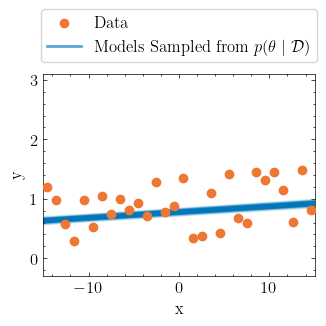

In [10]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('halfstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# Generate synthetic data
np.random.seed(0)

# Hyperparameters
sigma2 = 0.1  # Variance of the noise
tau2 = 30  # Prior variance
slope = 0.01
offset = 0.75
n = 200

X = np.linspace(-100, 100, n)

y = slope * X + offset + np.random.normal(0, np.sqrt(sigma2), n)

# Add a column of ones for the intercept term
X = np.vstack((np.ones(n), X)).T

# Posterior calculations
Sigma_prior = tau2 * np.eye(2)
Sigma_post = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma2) * X.T @ X)
mu_post = Sigma_post @ ((1 / sigma2) * X.T @ y)

# Sampling from the posterior distribution of parameters
n_samples = 100
samples = np.random.multivariate_normal(mu_post, Sigma_post, n_samples)

# Plotting
plt.figure()
plt.scatter(X[:, 1], y, label='Data', color=colors[0], alpha=1, zorder=3)

# Plot sampled linear models
X_plot = np.linspace(-15, 15, 100)
for theta in samples[:-1]:
    y_sampled = theta[0] + theta[1] * X_plot
    plt.plot(X_plot, y_sampled, color=colors[1], alpha=0.1)

y_sampled = theta[0] + theta[1] * X_plot
plt.plot([0,0], [0,0], color=colors[1], alpha=0.65, label="Models Sampled from $p(\\theta\mid\mathcal{D})$")

# Plot the mean line from the posterior
y_mean = mu_post[0] + mu_post[1] * X_plot
#plt.plot(X_plot, y_mean, label='Mean Model', color=colors[1])

plt.xlabel('x')
plt.ylabel('y')
plt.xlim([-15, 15])
plt.ylim([-0.3, 3.1])
plt.legend(bbox_to_anchor=(-0.01, 1.32), loc='upper left', borderaxespad=0., ncols=1)
#plt.tight_layout()
plt.savefig("outputs/sampled_linear_models_low_epistemic.pdf", format='pdf', bbox_inches='tight')
